# **Installing Libs**

In [ ]:
%%capture --no-stderr
%pip install -U langgraph langchain-community langchain-anthropic tavily-python pandas openai fuzzywuzzy

# **Loading the FAQ csv file (For testing use only):**

In [ ]:
faq_df = pd.read_csv('/content/faq.csv')

# **This is what the data looks like:**

In [ ]:
faq_df.head()

,question,answer
0,What is your company?,We are a technology company specializing in AI...
1,How can I contact support?,You can contact support via email at support@e...
2,Where are you located?,"Our headquarters is located in San Francisco, ..."
3,What services do you offer?,"We offer AI consulting, custom machine learnin..."
4,What is your return policy?,We offer a 30-day return policy for all produc...


# **Using the FAQ csv and building a simple support chatbot:**

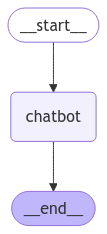

Text(value='', description='User:', placeholder='Type something...')

Button(description='Submit', style=ButtonStyle())

Assistant: We accept credit/debit cards, PayPal, and bank transfers.


In [ ]:
import pandas as pd
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from fuzzywuzzy import fuzz
import ipywidgets as widgets
from IPython.display import display

#Function to get an answer from the data source aka the test faq csv file:
def get_faq_answer(user_query: str) -> str:
    user_query = user_query.lower()
    best_match_score = 0
    best_match_answer = "Sorry, I couldn't find an answer to your question. Would you like me to search further?"

    for _, row in faq_df.iterrows():
        match_score = fuzz.partial_ratio(user_query, row['question'].lower())

        if match_score > best_match_score:
            best_match_score = match_score
            best_match_answer = row['answer']

    return best_match_answer

class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

llm = ChatOpenAI(model="gpt-4o-mini")

def chatbot(state: State):
    user_query = state["messages"][-1].content
    faq_answer = get_faq_answer(user_query)

    if faq_answer != "Sorry, I couldn't find an answer to your question. Would you like me to search further?":
        return {"messages": [{"role": "assistant", "content": faq_answer}]}

    return {"messages": [llm.invoke(state["messages"])]}

#Building the LangGraph:
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)
graph = graph_builder.compile()

#Displaying the Graph:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [("user", user_input)]}):
        for value in event.values():
            if isinstance(value, dict) and "messages" in value:
                for message in value["messages"]:
                    print("Assistant:", message["content"])


#Simple UI to make the testing easier:
def on_submit(user_input):
    stream_graph_updates(user_input)

user_input_box = widgets.Text(
    description='User:',
    placeholder='Type something...',
)

submit_button = widgets.Button(description="Submit")

submit_button.on_click(lambda x: on_submit(user_input_box.value))

display(user_input_box, submit_button)